# Lorenz-63 System


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
def lorenz_system(state, sigma=10.0, rho=28.0, beta=8/3):
    x, y, z = state
    
    dx_dt = sigma * (y - x)
    dy_dt = x * (rho - z) - y
    dz_dt = x * y - beta * z
    
    return np.array([dx_dt, dy_dt, dz_dt])

In [5]:
def rk4_step(state, dt):
    k1 = lorenz_system(state)
    k2 = lorenz_system(state + (dt / 2) * k1)
    k3 = lorenz_system(state + (dt / 2) * k2)
    k4 = lorenz_system(state + dt * k3)
    
    return state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

In [6]:
dt = 2.5e-2
total_steps = int(4e6)

In [7]:
current_state = np.array([1.0, 1.0, 1.0])
trajectory = []

In [8]:
for i in range(total_steps):
    trajectory.append(current_state)
    current_state = rk4_step(current_state, dt)

# Convert to a numpy array for easy handling
trajectory = np.array(trajectory)

print(f"Generated data shape: {trajectory.shape}")

Generated data shape: (4000000, 3)


In [9]:
trajectory[:5,:]

array([[1.        , 1.        , 1.        ],
       [1.07545053, 1.65930813, 0.96861164],
       [1.2876899 , 2.39988521, 0.96379682],
       [1.63448705, 3.30797486, 1.00201622],
       [2.13310847, 4.47105098, 1.11389662]])

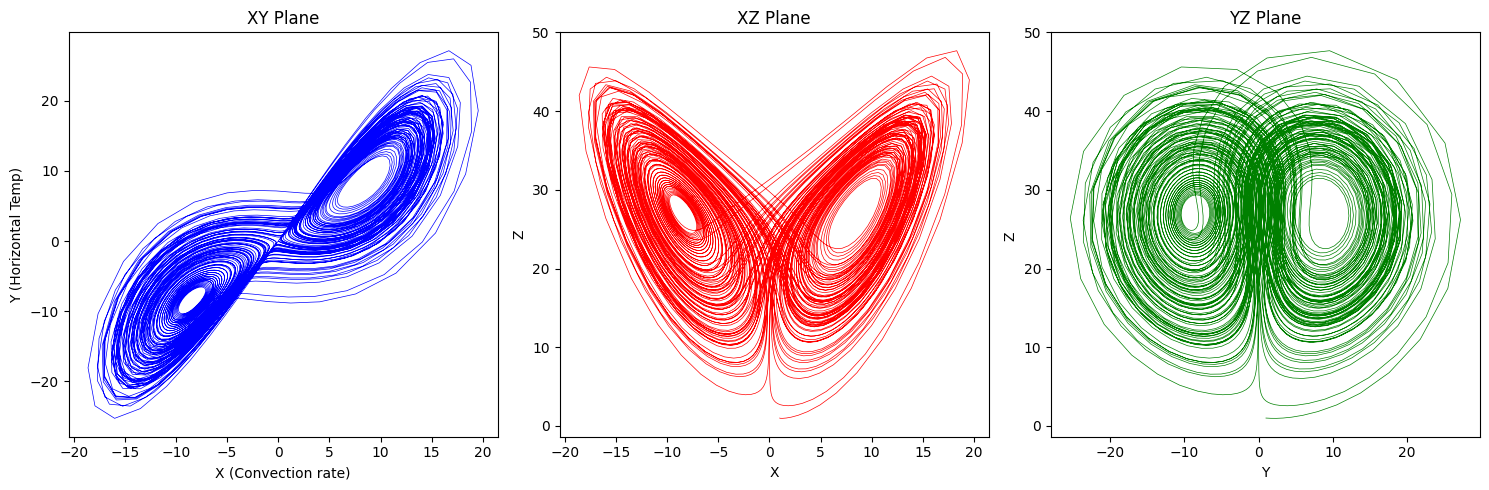

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(trajectory[:5000, 0], trajectory[:5000, 1], color='blue', lw=0.5)
ax1.set_xlabel('X (Convection rate)')
ax1.set_ylabel('Y (Horizontal Temp)')
ax1.set_title('XY Plane')


ax2.plot(trajectory[:5000, 0], trajectory[:5000, 2], color='red', lw=0.5)
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
ax2.set_title('XZ Plane')


ax3.plot(trajectory[:5000, 1], trajectory[:5000, 2], color='green', lw=0.5)
ax3.set_xlabel('Y')
ax3.set_ylabel('Z ')
ax3.set_title('YZ Plane')

plt.tight_layout()
plt.show()

In [11]:
n =2
state_dim = 3
window_size = n+1

def create_joint_windows(trajectory, window_size):
    total_steps = len(trajectory)
    num_possible_windows = total_steps - (window_size - 1)
    windows = []
    for i in range(num_possible_windows):
        window_segment = trajectory[i : i + window_size]
        flat_vector = window_segment.flatten()
        windows.append(flat_vector)

    return np.array(windows)

In [12]:
time_windows = create_joint_windows(trajectory,window_size)
print(f"Time window data shape: {time_windows.shape}")

Time window data shape: (3999998, 9)


In [13]:
print(time_windows[:5,:])

[[1.         1.         1.         1.07545053 1.65930813 0.96861164
  1.2876899  2.39988521 0.96379682]
 [1.07545053 1.65930813 0.96861164 1.2876899  2.39988521 0.96379682
  1.63448705 3.30797486 1.00201622]
 [1.2876899  2.39988521 0.96379682 1.63448705 3.30797486 1.00201622
  2.13310847 4.47105098 1.11389662]
 [1.63448705 3.30797486 1.00201622 2.13310847 4.47105098 1.11389662
  2.81735656 5.98633224 1.35396999]
 [2.13310847 4.47105098 1.11389662 2.81735656 5.98633224 1.35396999
  3.73651188 7.96341702 1.81773974]]


In [15]:
train_dataset = time_windows[:int(4e4),:]

In [16]:
train_mean = np.mean(train_dataset, axis=0)
train_std = np.std(train_dataset, axis=0)

epsilon = 1e-8

normalized_train_dataset = (train_dataset - train_mean) / (train_std + epsilon)

In [17]:
print(f'Number of time windows (samples) in the Training Dataset = {len(train_dataset)}')

Number of time windows (samples) in the Training Dataset = 40000


In [18]:
class ConditionalJointDataset(Dataset): 
    def __init__(self, windows, n, state_dim):
        self.data =torch.tensor(windows, dtype=torch.float32)
        self.n = n
        self.state_dim = state_dim
        self.history_end = n * state_dim
        self.target_start = state_dim            

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        row = self.data[idx]                                  
        history = row[:self.history_end]                    
        target  = row[self.target_start:self.target_start + self.history_end] 
        return history, target

In [19]:
train_dataset = ConditionalJointDataset(normalized_train_dataset,n=n,state_dim=state_dim)
train_loader = DataLoader(train_dataset, batch_size=500, shuffle=True, num_workers=0)

In [20]:
class ConditionalJointNADE(nn.Module):
    def __init__(self, target_dim=6, history_dim=6, hidden_dim =1000):
        super().__init__()
        self.target_dim  = target_dim
        self.history_dim = history_dim
        self.hidden_dim  = hidden_dim

        self.W = nn.Parameter(torch.randn(hidden_dim, target_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))    # bias
        self.U = nn.Linear(history_dim, hidden_dim, bias=False)

        self.V_mu = nn.Parameter(torch.randn(target_dim, hidden_dim) * 0.01)
        self.b_mu = nn.Parameter(torch.zeros(target_dim))
        self.V_log_sigma = nn.Parameter(torch.randn(target_dim, hidden_dim) * 0.01)
        self.b_log_sigma = nn.Parameter(torch.zeros(target_dim))


    def forward(self,x, history):
        B = x.shape[0] 
        mu_out = torch.zeros(B, self.target_dim, device=x.device)
        log_sigma_out = torch.zeros(B, self.target_dim, device=x.device)
        a = self.c.unsqueeze(0).expand(B, -1) + self.U(history)

        for i in range(self.target_dim):
            h = torch.relu(a)
            mu_i = h @ self.V_mu[i]+ self.b_mu[i]
            log_sigma_i = h @ self.V_log_sigma[i] + self.b_log_sigma[i]
            log_sigma_i = torch.clamp(log_sigma_i, min=-5, max=2)
            mu_out[:, i]        = mu_i
            log_sigma_out[:, i] = log_sigma_i
            if i < self.target_dim - 1:
                a = a + x[:, i].unsqueeze(1) * self.W[:, i].unsqueeze(0)
        return mu_out, log_sigma_out


    @torch.no_grad()
    def sample(self, history):
        B = history.shape[0]
        samples = torch.zeros(B, self.target_dim, device=history.device)
        a = self.c.unsqueeze(0).expand(B, -1) + self.U(history)

        for i in range(self.target_dim):
            h = torch.relu(a)
            mu_i = h @ self.V_mu[i] + self.b_mu[i]
            log_sigma_i = h @ self.V_log_sigma[i] + self.b_log_sigma[i]
            log_sigma_i = torch.clamp(log_sigma_i, min=-5, max=2)
            sigma_i = torch.exp(log_sigma_i)
            x_i = mu_i + sigma_i * torch.randn(B, device=history.device)
            samples[:, i] = x_i
            if i < self.target_dim - 1:
                a = a + x_i.unsqueeze(1) * self.W[:, i].unsqueeze(0)

        return samples


In [21]:
def gaussian_nll_loss(mu, log_sigma, target):
    variance = torch.exp(log_sigma) ** 2
    loss = 0.5 * ((target - mu) ** 2 / variance) + log_sigma + 0.5 * np.log(2 * np.pi)
    # Sum across the 6 dimensions, then get the mean for the batch
    return loss.sum(dim=1).mean()

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConditionalJointNADE(6,6, hidden_dim=1000).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001) 
loss_history = []
epochs = 50


In [23]:
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for batch_history, batch_target in train_loader:
        batch_history = batch_history.to(device)
        batch_target  = batch_target.to(device)
        optimizer.zero_grad()
        mu,log_sigma = model(batch_target, batch_history)
        loss = gaussian_nll_loss(mu, log_sigma, batch_target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | NLL loss: {avg_loss:.4f}")


Epoch   5/50 | NLL loss: -4.4631
Epoch  10/50 | NLL loss: -14.8054
Epoch  15/50 | NLL loss: -21.1938
Epoch  20/50 | NLL loss: -22.1983
Epoch  25/50 | NLL loss: -21.1147
Epoch  30/50 | NLL loss: -23.4943
Epoch  35/50 | NLL loss: -20.5886
Epoch  40/50 | NLL loss: -23.4868
Epoch  45/50 | NLL loss: -23.3499
Epoch  50/50 | NLL loss: -20.3562


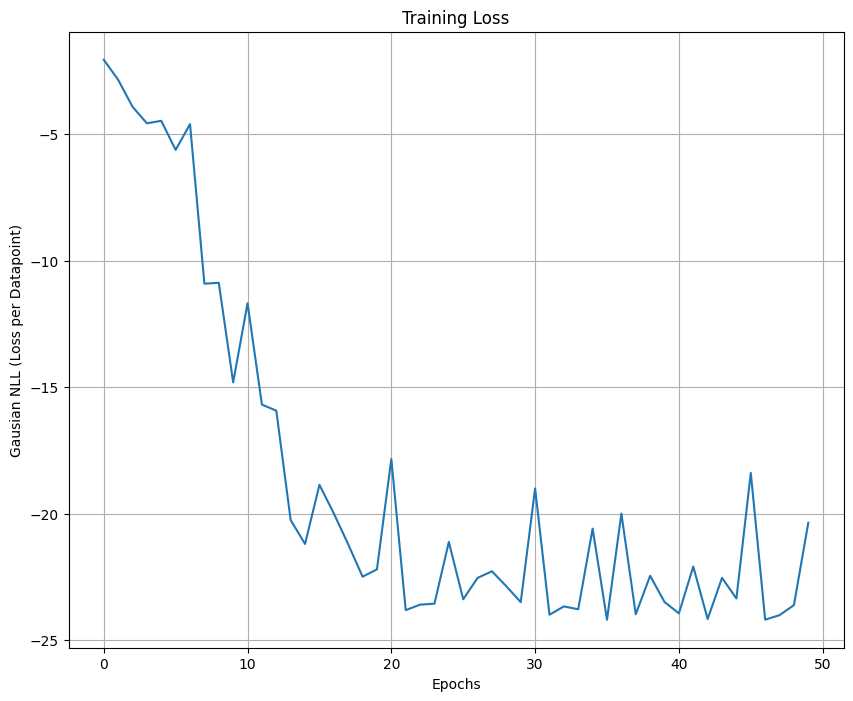

In [24]:
plt.figure(figsize=(10,8))
plt.plot(range(epochs),loss_history)
plt.xlabel('Epochs')
plt.ylabel('Gausian NLL (Loss per Datapoint)')
plt.title('Training Loss')
plt.grid(True)


In [25]:
available_ground_truth = time_windows[int(4e4),:]
print(f'Avaible ground truth at last time step {available_ground_truth}')

Avaible ground truth at last time step [ -5.24735532  -8.15655177  17.50390855  -6.0326469   -9.41369435
  17.57328016  -6.93994965 -10.8172527   18.02765351]


In [31]:
N = 1000
forecast_horizon = int(2e4)
forecasted_trajectory = []

current_history_unnorm = torch.tensor(available_ground_truth[:6], dtype=torch.float32).to(device)

mu_tensor = torch.tensor(train_mean, dtype=torch.float32, device=device)
std_tensor = torch.tensor(train_std, dtype=torch.float32, device=device)

In [32]:
model.eval()
with torch.no_grad():
    for t in range(forecast_horizon):
        current_history_norm = (current_history_unnorm - mu_tensor[:6]) / (std_tensor[:6] + 1e-8)
        batch_history = current_history_norm.unsqueeze(0).expand(N, -1)
        candidates_norm = model.sample(batch_history)
        candidates_unnorm = (candidates_norm * std_tensor[3:9]) + mu_tensor[3:9]
        candidate_tails = candidates_unnorm[:, :3] 
        candidate_heads = candidates_unnorm[:, 3:] 
        most_recent_observation = current_history_unnorm[3:] 
        distances = torch.norm(candidate_tails - most_recent_observation, dim=1)
        best_index = torch.argmin(distances)
        winning_forecast = candidate_heads[best_index]
        forecasted_trajectory.append(winning_forecast.cpu().numpy())
        current_history_unnorm = torch.cat([most_recent_observation, winning_forecast])
        if (t + 1) % 100 == 0:
            print(f"Forecasted {t+1}/{forecast_horizon} steps")

forecasted_trajectory = np.array(forecasted_trajectory)
print(f"Forecasting complete! Shape: {forecasted_trajectory.shape}")

Forecasted 100/20000 steps
Forecasted 200/20000 steps
Forecasted 300/20000 steps
Forecasted 400/20000 steps
Forecasted 500/20000 steps
Forecasted 600/20000 steps
Forecasted 700/20000 steps
Forecasted 800/20000 steps
Forecasted 900/20000 steps
Forecasted 1000/20000 steps
Forecasted 1100/20000 steps
Forecasted 1200/20000 steps
Forecasted 1300/20000 steps
Forecasted 1400/20000 steps
Forecasted 1500/20000 steps
Forecasted 1600/20000 steps
Forecasted 1700/20000 steps
Forecasted 1800/20000 steps
Forecasted 1900/20000 steps
Forecasted 2000/20000 steps
Forecasted 2100/20000 steps
Forecasted 2200/20000 steps
Forecasted 2300/20000 steps
Forecasted 2400/20000 steps
Forecasted 2500/20000 steps
Forecasted 2600/20000 steps
Forecasted 2700/20000 steps
Forecasted 2800/20000 steps
Forecasted 2900/20000 steps
Forecasted 3000/20000 steps
Forecasted 3100/20000 steps
Forecasted 3200/20000 steps
Forecasted 3300/20000 steps
Forecasted 3400/20000 steps
Forecasted 3500/20000 steps
Forecasted 3600/20000 steps
F

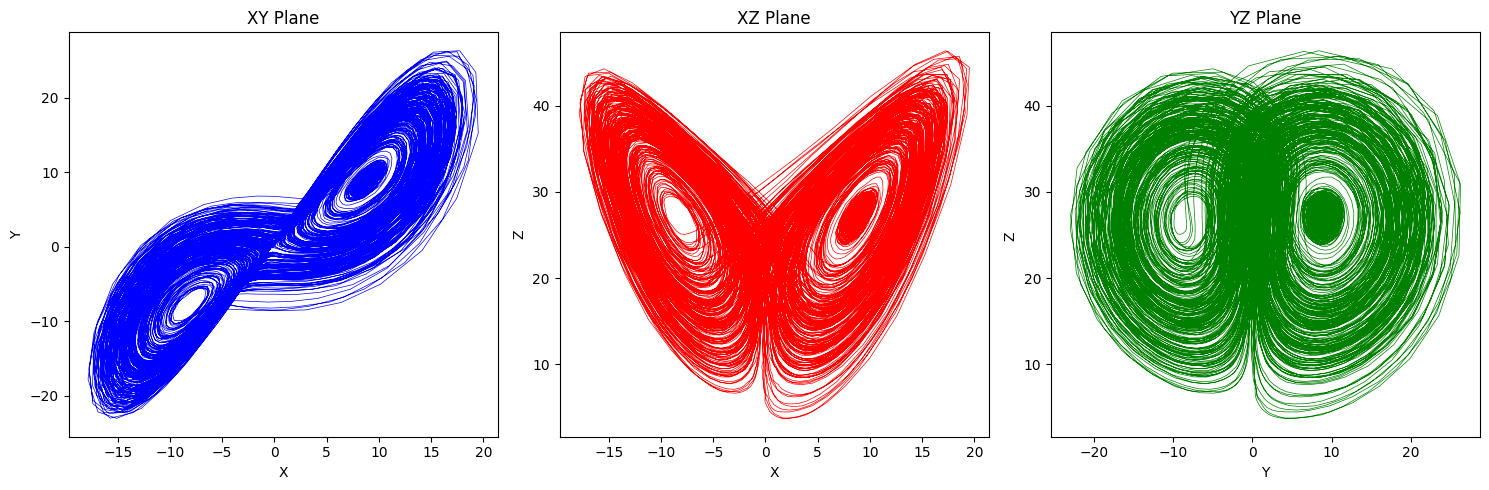

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(forecasted_trajectory[:, 0], forecasted_trajectory[:, 1], color='blue', lw=0.5)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title('XY Plane')


ax2.plot(forecasted_trajectory[:, 0], forecasted_trajectory[:, 2], color='red', lw=0.5)
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
ax2.set_title('XZ Plane')


ax3.plot(forecasted_trajectory[:, 1], forecasted_trajectory[:, 2], color='green', lw=0.5)
ax3.set_xlabel('Y')
ax3.set_ylabel('Z ')
ax3.set_title('YZ Plane')

plt.tight_layout()
plt.show()

# Distribution Adherence Test Plots

In [34]:
all_data = trajectory[:]
train_data = trajectory[:40000,:]
truth_data = trajectory[40000:40000+forecast_horizon,:]
pred_data = forecasted_trajectory[:]


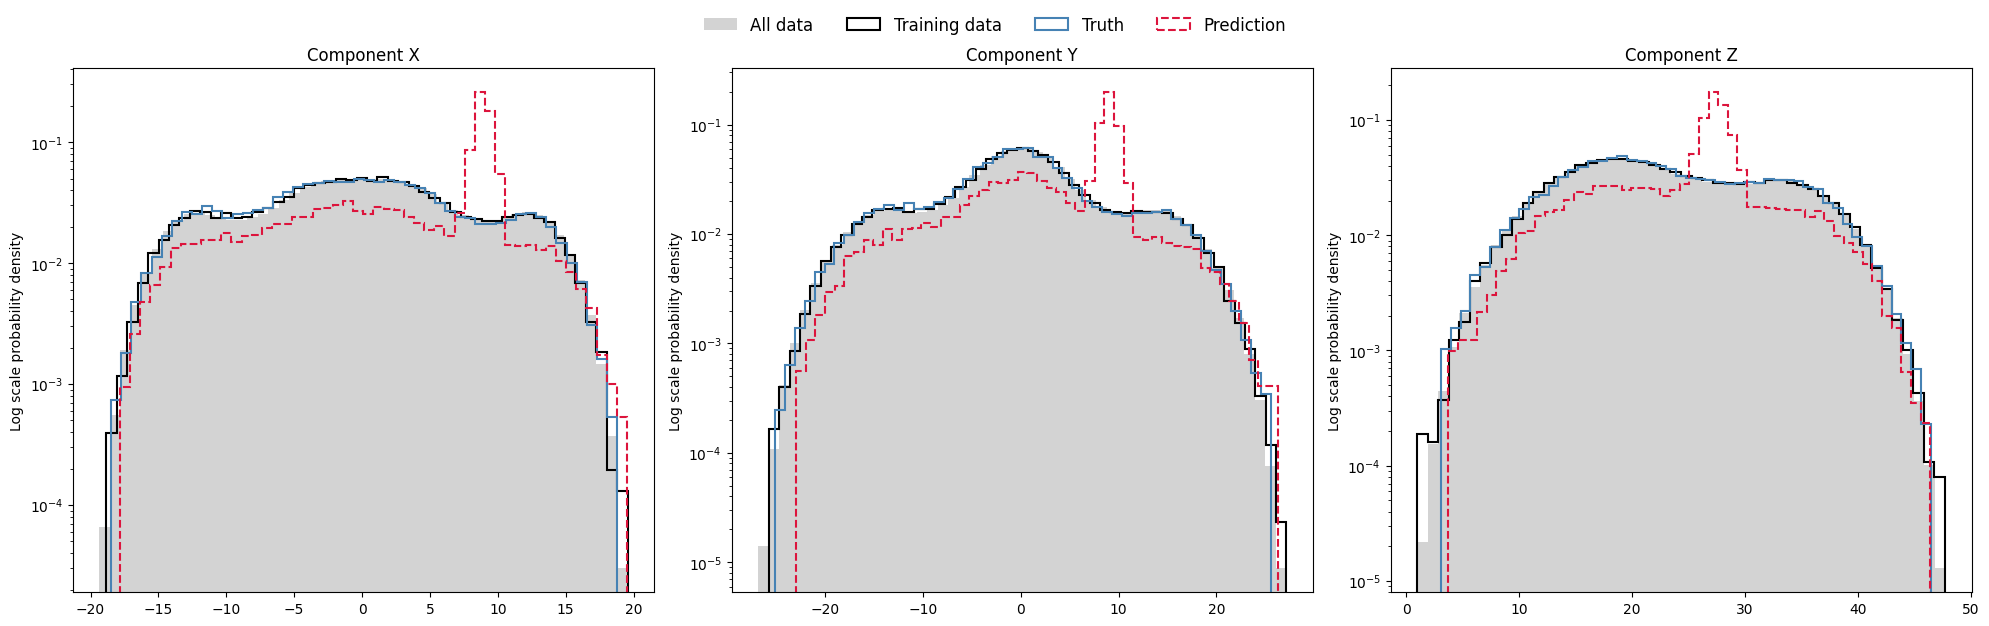

In [35]:
fig, axes = plt.subplots(1,3,figsize=(20,6))
variables = ['x','y','z']
bins = 50

for i in range(3):
    ax = axes[i]
    ax.hist(all_data[:, i], bins=bins, density=True, log=True, color='lightgrey',label='All data' if i==0 else "")
    ax.hist(train_data[:, i], bins=bins, density=True, log=True, histtype='step',color='black', linewidth=1.5, label='Training data' if i==0 else "")
    ax.hist(truth_data[:, i], bins=bins, density=True, log=True, histtype='step',color='steelblue', linewidth=1.5, label='Truth' if i==0 else "")
    ax.hist(pred_data[:, i], bins=bins, density=True, log=True, histtype='step',linestyle='--', color='crimson', linewidth=1.5, label='Prediction' if i==0 else "")
    ax.set_ylabel('Log scale probability density')
    ax.set_title(f'Component {variables[i].upper()}')

fig.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05), frameon=False, fontsize=12)

plt.tight_layout()
plt.show()
        

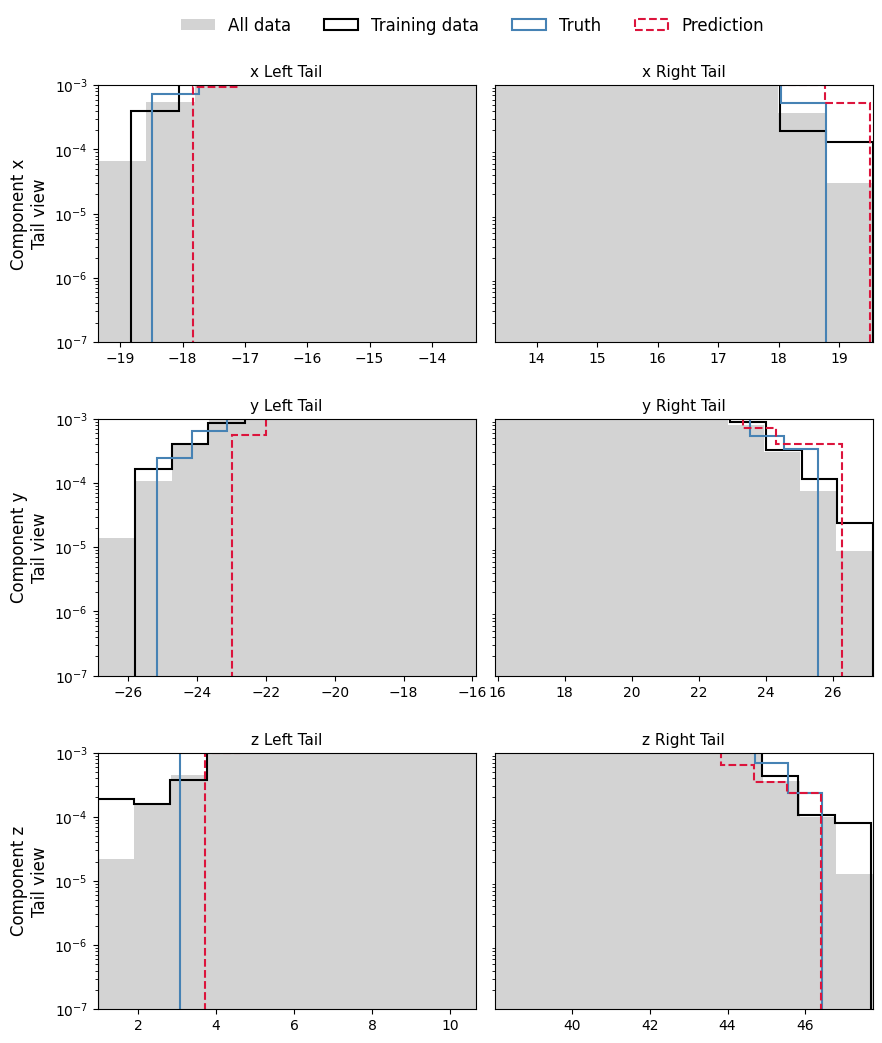

In [36]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12), sharey='row', gridspec_kw={'wspace': 0.05, 'hspace': 0.3})

for i in range(3):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]
    
    for ax in [ax_left, ax_right]:
        ax.hist(all_data[:, i], bins=bins, density=True, log=True, color='lightgrey', 
                label='All data' if i==0 and ax==ax_left else "")
        ax.hist(train_data[:, i], bins=bins, density=True, log=True, histtype='step', 
                color='black', linewidth=1.5, label='Training data' if i==0 and ax==ax_left else "")
        ax.hist(truth_data[:, i], bins=bins, density=True, log=True, histtype='step', 
                color='steelblue', linewidth=1.5, label='Truth' if i==0 and ax==ax_left else "")
        ax.hist(pred_data[:, i], bins=bins, density=True, log=True, histtype='step', 
                linestyle='--', color='crimson', linewidth=1.5, label='Prediction' if i==0 and ax==ax_left else "")
        
        ax.set_ylim(1e-7, 1e-3)
        

    ax_right.tick_params(axis='y', left=False)
    
    left_tail_max = np.percentile(all_data[:, i], 5)
    right_tail_min = np.percentile(all_data[:, i], 95)
    
    ax_left.set_xlim(np.min(all_data[:, i]), left_tail_max)
    ax_right.set_xlim(right_tail_min, np.max(all_data[:, i]))
    
    ax_left.set_ylabel(f'Component {variables[i]}\nTail view', fontsize=12)
    ax_left.set_title(f'{variables[i]} Left Tail', fontsize=11)
    ax_right.set_title(f'{variables[i]} Right Tail', fontsize=11)


fig.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.95), frameon=False, fontsize=12)


plt.subplots_adjust(top=0.88) 

plt.show()